<a href="https://colab.research.google.com/github/GabyPugaBR/AAI2025/blob/main/supplyChainAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inventory Replenishment Agent (CSV Version)

This notebook replaces synthetic demand generation with CSV files:

- `sales.csv`
- `inventory.csv`
- `params.csv`

The goal is to:
1. Load and prepare daily demand by SKU
2. Forecast demand with EWMA
3. Compute safety stock from forecast error and service level
4. Let an agent decide when to order inventory
5. Simulate inventory outcomes and costs
6. Print detailed daily logs

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from collections import deque
import matplotlib.pyplot as plt

## Global Parameters

Change the SKU or override some values to experiment.

In [2]:
# --- GLOBAL SIMULATION PARAMETERS ---
SIMULATION_DAYS = 90
SKU_ID = "SKU_A"

# Default fallback values if you want to override CSV behavior
REVIEW_PERIOD = 1
ALPHA = 0.2                        # increased from 0.1 — more responsive to recent demand
ORDER_COST_FIXED_OVERRIDE = None   # set to a number like 50.0 if you want to override CSV

## Load CSV Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
sales = pd.read_csv("/content/drive/MyDrive/Team Static - Agentic AI in Supply Chain (in progress)/sales.csv", parse_dates=["date"])
inventory = pd.read_csv("/content/drive/MyDrive/Team Static - Agentic AI in Supply Chain (in progress)/inventory.csv")
params = pd.read_csv("/content/drive/MyDrive/Team Static - Agentic AI in Supply Chain (in progress)/params.csv")

display(sales.head(), inventory.head(), params.head())

,date,sku,qty_sold
0,2025-01-01,SKU_A,22
1,2025-01-01,SKU_B,15
2,2025-01-01,SKU_C,9
3,2025-01-02,SKU_A,24
4,2025-01-02,SKU_B,14


,sku,opening_stock
0,SKU_A,220
1,SKU_B,140
2,SKU_C,95


,sku,unit_cost,holding_cost_per_day,stockout_cost,lead_time_days,min_order_qty,service_level
0,SKU_A,12.50,0.04,8.0,5,60,0.95
1,SKU_B,8.75,0.03,6.5,7,40,0.95
2,SKU_C,5.20,0.02,5.0,10,30,0.99


## Prepare Daily Demand for One SKU

In [7]:
daily = (
    sales.groupby(["date", "sku"], as_index=False)["qty_sold"]
    .sum()
    .rename(columns={"qty_sold": "Demand"})
    .sort_values(["sku", "date"])
)

sku_demand = daily[daily["sku"] == SKU_ID].copy().reset_index(drop=True)

if sku_demand.empty:
    raise ValueError(f"SKU '{SKU_ID}' not found in sales.csv")

sku_demand = sku_demand.head(SIMULATION_DAYS).copy()
sku_demand["Day"] = range(1, len(sku_demand) + 1)

sku_inv = inventory[inventory["sku"] == SKU_ID]
sku_par = params[params["sku"] == SKU_ID]

if sku_inv.empty:
    raise ValueError(f"SKU '{SKU_ID}' not found in inventory.csv")
if sku_par.empty:
    raise ValueError(f"SKU '{SKU_ID}' not found in params.csv")

INITIAL_INVENTORY = int(sku_inv["opening_stock"].iloc[0])

LEAD_TIME = int(sku_par["lead_time_days"].iloc[0])
SERVICE_LEVEL = float(sku_par["service_level"].iloc[0])
MIN_ORDER_QTY = int(sku_par["min_order_qty"].iloc[0])

HOLDING_COST_PER_UNIT = float(sku_par["holding_cost_per_day"].iloc[0])
STOCKOUT_COST_PER_UNIT = float(sku_par["stockout_cost"].iloc[0])

ORDER_COST_FIXED = (
    ORDER_COST_FIXED_OVERRIDE
    if ORDER_COST_FIXED_OVERRIDE is not None
    else 0.0
)

print("SKU:", SKU_ID)
print("Days:", len(sku_demand))
print("Initial inventory:", INITIAL_INVENTORY)
print("Lead time:", LEAD_TIME)
print("Service level:", SERVICE_LEVEL)
print("MOQ:", MIN_ORDER_QTY)
print("Holding cost:", HOLDING_COST_PER_UNIT)
print("Stockout cost:", STOCKOUT_COST_PER_UNIT)
print("Order cost fixed:", ORDER_COST_FIXED)

sku_demand.head()



SKU: SKU_A
Days: 90
Initial inventory: 220
Lead time: 5
Service level: 0.95
MOQ: 60
Holding cost: 0.04
Stockout cost: 8.0
Order cost fixed: 0.0


,date,sku,Demand,Day
0,2025-01-01,SKU_A,22,1
1,2025-01-02,SKU_A,24,2
2,2025-01-03,SKU_A,25,3
3,2025-01-04,SKU_A,27,4
4,2025-01-05,SKU_A,27,5


## Plot Demands

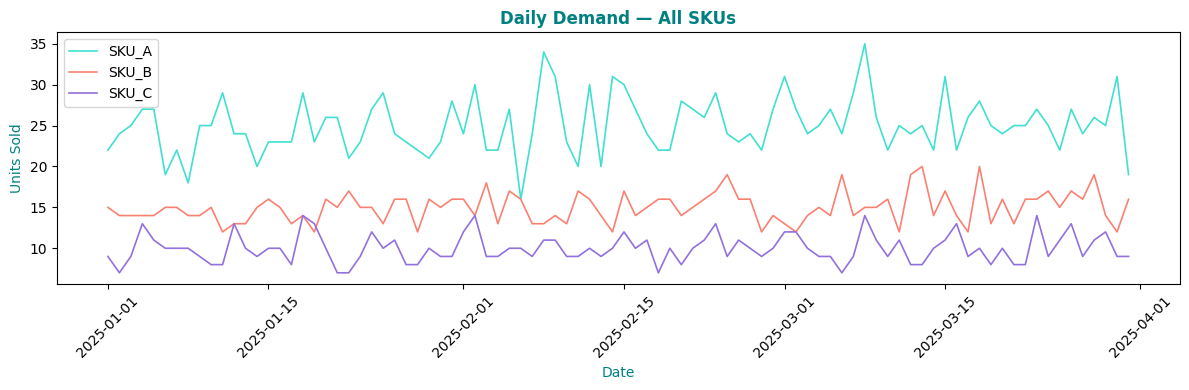

In [8]:
colors = {"SKU_A": "turquoise", "SKU_B": "salmon", "SKU_C": "mediumpurple"}

plt.figure(figsize=(12, 4))

for sku_id in daily["sku"].unique():
    sku_data = daily[daily["sku"] == sku_id]
    plt.plot(sku_data["date"], sku_data["Demand"], label=sku_id, color=colors.get(sku_id, "gray"), linewidth=1.2)

plt.title("Daily Demand — All SKUs", color="teal", fontweight="bold")
plt.xlabel("Date", color="teal")
plt.ylabel("Units Sold", color="teal")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Agent Definition


In [9]:
class InventoryAgent:
    """
    The core agent system for inventory replenishment.
    It forecasts demand, calculates safety stock, and makes daily order decisions.
    """
    def __init__(self, initial_inventory, sku_params):
        self.sku_id = sku_params['sku_id']
        self.L = sku_params['lead_time']
        self.R = sku_params['review_period']
        self.SL = sku_params['service_level']
        self.MOQ = sku_params['min_order_qty']
        self.ALPHA = sku_params['alpha']

        # Financials
        self.H_COST = sku_params['holding_cost']
        self.S_COST = sku_params['stockout_cost']
        self.O_COST = sku_params['order_cost']

        # Agent state
        self.inventory_on_hand = initial_inventory
        self.forecast_history = []
        self.error_history = []
        self.po_in_transit = deque()  # Queue of (quantity, arrival_day)
        self.backorders = 0
        self.is_review_day = False

        # Determine the Z-score for the target service level
        self.Z = norm.ppf(self.SL)

    def forecast_demand(self, actual_demand):
        """EWMA forecast"""
        if not self.forecast_history:
            forecast = actual_demand
        else:
            last_demand = self.error_history[-1]['ActualDemand'] if self.error_history else actual_demand
            last_forecast = self.forecast_history[-1]
            forecast = (self.ALPHA * last_demand) + ((1 - self.ALPHA) * last_forecast)

        self.forecast_history.append(forecast)
        return round(forecast)

    def calculate_safety_stock(self):
        """
        Safety stock based on forecast error and risk period = L + R.
        Bootstraps with a simple Z*(L+R) estimate until enough error history exists.
        """
        if len(self.error_history) < 5:
            # FIX 3: bootstrap safety stock instead of returning 0
            return round(self.Z * (self.L + self.R))

        errors = [abs(e['Error']) for e in self.error_history]
        stdev_error = np.std(errors)
        safety_stock = self.Z * stdev_error * np.sqrt(self.L + self.R)
        return round(safety_stock)

    def make_decision(self, current_day, daily_demand, total_inventory):
        log = []

        self.is_review_day = (current_day - 1) % self.R == 0
        if not self.is_review_day:
            log.append("REVIEW: NO - Not a review day.")
            return 0, log

        risk_period = self.L + self.R
        daily_forecast = self.forecast_history[-1] if self.forecast_history else daily_demand
        forecast_risk_period = daily_forecast * risk_period

        log.append(f"FORECAST: Daily={daily_forecast}, Risk Period ({risk_period} days)={forecast_risk_period}")

        safety_stock = self.calculate_safety_stock()
        target_inventory = forecast_risk_period + safety_stock
        log.append(f"SAFETY STOCK: Z={self.Z:.2f}, SS={safety_stock}, Target Inventory={target_inventory}")

        total_in_transit = sum(q for q, arrival in self.po_in_transit)
        inventory_position = self.inventory_on_hand + total_in_transit - self.backorders
        log.append(f"INVENTORY POSITION: IOH={self.inventory_on_hand} + PO={total_in_transit} - BO={self.backorders} = {inventory_position}")

        order_qty = target_inventory - inventory_position

        # FIX 1: MOQ is a minimum order size, not an ordering threshold.
        # Order whenever there is any gap; round up to MOQ if needed.
        if order_qty > 0:
            order_qty = max(int(np.ceil(order_qty)), self.MOQ)
            arrival_day = current_day + self.L
            self.po_in_transit.append((order_qty, arrival_day))
            log.append(f"DECISION: ORDER {order_qty}. IP ({inventory_position}) < Target ({target_inventory}). Arriving Day {arrival_day}")
            return order_qty, log
        else:
            log.append(f"DECISION: WAIT (No Order). IP ({inventory_position}) >= Target ({target_inventory}).")
            return 0, log

## Simulation Engine

This follows the same daily sequence as the original notebook:
1. arrivals
2. clear backorders
3. fulfill demand
4. decision
5. cost tracking
6. forecast error update
7. new forecast

In [10]:
class SimulationEngine:
    """Manages the daily loop, inventory updates, cost tracking, and logging."""
    def __init__(self, agent, demand_data):
        self.agent = agent
        self.demand_data = demand_data
        self.metrics = {
            'holding_cost': 0,
            'stockout_cost': 0,
            'order_cost': 0,
            'total_demand': 0,
            'fulfilled_demand': 0,
            'stockout_count': 0,
            'daily_log': []
        }

    def run_day(self, day, daily_demand):
        log = [f"--- DAY {day}: Demand={daily_demand} ---"]

        # A. Check for incoming orders — FIX 2: loop to receive ALL POs arriving today
        newly_arrived_qty = 0
        remaining_pos = deque()
        while self.agent.po_in_transit:
            qty, arrival_day = self.agent.po_in_transit.popleft()
            if arrival_day == day:
                self.agent.inventory_on_hand += qty
                newly_arrived_qty += qty
            else:
                remaining_pos.append((qty, arrival_day))
        self.agent.po_in_transit = remaining_pos

        if newly_arrived_qty > 0:
            log.append(f"ARRIVAL: Received {newly_arrived_qty} units. IOH is now {self.agent.inventory_on_hand}.")
        else:
            log.append("ARRIVAL: No PO received.")

        # B. Process demand & backorders
        demand_to_fulfill = daily_demand
        self.metrics['total_demand'] += demand_to_fulfill

        if self.agent.backorders > 0:
            fulfill_bo = min(self.agent.backorders, self.agent.inventory_on_hand)
            self.agent.backorders -= fulfill_bo
            self.agent.inventory_on_hand -= fulfill_bo
            log.append(f"FULFILLMENT: Cleared {fulfill_bo} backorders. Remaining BO: {self.agent.backorders}.")

        if self.agent.inventory_on_hand >= demand_to_fulfill:
            self.agent.inventory_on_hand -= demand_to_fulfill
            self.metrics['fulfilled_demand'] += demand_to_fulfill
            log.append(f"FULFILLMENT: Fulfilled {demand_to_fulfill} units. IOH: {self.agent.inventory_on_hand}.")
        else:
            fulfilled = self.agent.inventory_on_hand
            stockout = demand_to_fulfill - fulfilled

            self.agent.inventory_on_hand = 0
            self.agent.backorders += stockout

            self.metrics['fulfilled_demand'] += fulfilled
            self.metrics['stockout_count'] += 1

            log.append(f"STOCKOUT: Only {fulfilled} fulfilled. {stockout} units added to backorders (Total BO: {self.agent.backorders}).")

        # C. Decision
        order_qty, agent_log = self.agent.make_decision(day, daily_demand, self.agent.inventory_on_hand)
        log.extend(agent_log)

        # D. Costs
        holding_cost = self.agent.inventory_on_hand * self.agent.H_COST
        self.metrics['holding_cost'] += holding_cost

        stockout_cost = self.agent.backorders * self.agent.S_COST
        self.metrics['stockout_cost'] += stockout_cost

        if order_qty > 0:
            order_cost = self.agent.O_COST
            self.metrics['order_cost'] += order_cost
        else:
            order_cost = 0

        log.append(f"COSTS: Holding=${holding_cost:.2f}, Stockout=${stockout_cost:.2f}, Order=${order_cost:.2f}. Total Orders In Transit: {len(self.agent.po_in_transit)}")

        # E. Forecast error update
        if len(self.agent.forecast_history) > 0:
            yesterday_demand = self.demand_data.loc[self.demand_data['Day'] == day - 1, 'Demand'].iloc[0] if day > 1 else daily_demand
            latest_forecast = self.agent.forecast_history[-1]

            error = yesterday_demand - latest_forecast
            self.agent.error_history.append({
                'Day': day,
                'ActualDemand': yesterday_demand,
                'Forecast': latest_forecast,
                'Error': error
            })

        # F. New forecast
        new_forecast = self.agent.forecast_demand(daily_demand)
        log.append(f"FORECAST UPDATE: New Forecast (for tomorrow's decision)={new_forecast}")

        self.metrics['daily_log'].append(log)

    def run_simulation(self):
        print(f"--- Running Inventory Replenishment Simulation for {len(self.demand_data)} Days ---")
        print(f"SKU: {self.agent.sku_id}, Service Level: {self.agent.SL*100}%, Lead Time: {self.agent.L} days\n")

        for _, row in self.demand_data.iterrows():
            self.run_day(row['Day'], row['Demand'])

    def print_results(self):
        total_cost = self.metrics['holding_cost'] + self.metrics['stockout_cost'] + self.metrics['order_cost']
        fill_rate = self.metrics['fulfilled_demand'] / self.metrics['total_demand'] if self.metrics['total_demand'] > 0 else 0

        print("\n" + "="*50)
        print("SIMULATION RESULTS")
        print("="*50)

        print(f"\n[ PERFORMANCE METRICS ]")
        print(f"Total Demand:              {self.metrics['total_demand']:,} units")
        print(f"Total Fulfilled:           {self.metrics['fulfilled_demand']:,} units")
        print(f"Fill Rate (Orders Met):    {fill_rate:.2%}")
        print(f"Total Stockout Days:       {self.metrics['stockout_count']}")
        print(f"Final Inventory On Hand:   {self.agent.inventory_on_hand} units")
        print(f"Final Backorders:          {self.agent.backorders} units")

        print(f"\n[ FINANCIAL METRICS ]")
        print(f"Total Holding Cost:        ${self.metrics['holding_cost']:.2f}")
        print(f"Total Stockout Cost:       ${self.metrics['stockout_cost']:.2f}")
        print(f"Total Order Cost (Fixed):  ${self.metrics['order_cost']:.2f}")
        print(f"TOTAL SYSTEM COST:         ${total_cost:.2f}")
        print("="*50)

        print("\n--- DAILY AGENT LOG (First 5 Days) ---")
        for log in self.metrics['daily_log'][:5]:
            for line in log:
                print(f"| {line}")
            print("-" * 25)

        print("\n--- DAILY AGENT LOG (Last 5 Days) ---")
        for log in self.metrics['daily_log'][-5:]:
            for line in log:
                print(f"| {line}")
            print("-" * 25)

## Define SKU Parameters

In [11]:
sku_parameters = {
    'sku_id': SKU_ID,
    'lead_time': LEAD_TIME,
    'review_period': REVIEW_PERIOD,
    'service_level': SERVICE_LEVEL,
    'min_order_qty': MIN_ORDER_QTY,
    'alpha': ALPHA,
    'holding_cost': HOLDING_COST_PER_UNIT,
    'stockout_cost': STOCKOUT_COST_PER_UNIT,
    'order_cost': ORDER_COST_FIXED
}

## Run the Simulation

In [12]:
agent = InventoryAgent(INITIAL_INVENTORY, sku_parameters)
sim = SimulationEngine(agent, sku_demand[["Day", "Demand"]])

sim.run_simulation()
sim.print_results()

--- Running Inventory Replenishment Simulation for 90 Days ---
SKU: SKU_A, Service Level: 95.0%, Lead Time: 5 days


SIMULATION RESULTS

[ PERFORMANCE METRICS ]
Total Demand:              2,252 units
Total Fulfilled:           2,252 units
Fill Rate (Orders Met):    100.00%
Total Stockout Days:       0
Final Inventory On Hand:   68 units
Final Backorders:          0 units

[ FINANCIAL METRICS ]
Total Holding Cost:        $247.44
Total Stockout Cost:       $0.00
Total Order Cost (Fixed):  $0.00
TOTAL SYSTEM COST:         $247.44

--- DAILY AGENT LOG (First 5 Days) ---
| --- DAY 1: Demand=22 ---
| ARRIVAL: No PO received.
| FULFILLMENT: Fulfilled 22 units. IOH: 198.
| FORECAST: Daily=22, Risk Period (6 days)=132
| SAFETY STOCK: Z=1.64, SS=10, Target Inventory=142
| INVENTORY POSITION: IOH=198 + PO=0 - BO=0 = 198
| DECISION: WAIT (No Order). IP (198) >= Target (142).
| COSTS: Holding=$7.92, Stockout=$0.00, Order=$0.00. Total Orders In Transit: 0
| FORECAST UPDATE: New Forecast (for tomorro

## Inspect Daily Log as Raw Python Output

In [13]:
sim.metrics["daily_log"][:3]

[['--- DAY 1: Demand=22 ---',
  'ARRIVAL: No PO received.',
  'FULFILLMENT: Fulfilled 22 units. IOH: 198.',
  'FORECAST: Daily=22, Risk Period (6 days)=132',
  'SAFETY STOCK: Z=1.64, SS=10, Target Inventory=142',
  'INVENTORY POSITION: IOH=198 + PO=0 - BO=0 = 198',
  'DECISION: WAIT (No Order). IP (198) >= Target (142).',
  'COSTS: Holding=$7.92, Stockout=$0.00, Order=$0.00. Total Orders In Transit: 0',
  "FORECAST UPDATE: New Forecast (for tomorrow's decision)=22"],
 ['--- DAY 2: Demand=24 ---',
  'ARRIVAL: No PO received.',
  'FULFILLMENT: Fulfilled 24 units. IOH: 174.',
  'FORECAST: Daily=22, Risk Period (6 days)=132',
  'SAFETY STOCK: Z=1.64, SS=10, Target Inventory=142',
  'INVENTORY POSITION: IOH=174 + PO=0 - BO=0 = 174',
  'DECISION: WAIT (No Order). IP (174) >= Target (142).',
  'COSTS: Holding=$6.96, Stockout=$0.00, Order=$0.00. Total Orders In Transit: 0',
  "FORECAST UPDATE: New Forecast (for tomorrow's decision)=22"],
 ['--- DAY 3: Demand=25 ---',
  'ARRIVAL: No PO received

## Table of daily log

In [14]:
flat_logs = []
for day_idx, day_log in enumerate(sim.metrics["daily_log"], start=1):
    flat_logs.append({
        "Day": day_idx,
        "Log": " | ".join(day_log)
    })

log_df = pd.DataFrame(flat_logs)
display(log_df.head(10))

,Day,Log
0,1,--- DAY 1: Demand=22 --- | ARRIVAL: No PO rece...
1,2,--- DAY 2: Demand=24 --- | ARRIVAL: No PO rece...
2,3,--- DAY 3: Demand=25 --- | ARRIVAL: No PO rece...
3,4,--- DAY 4: Demand=27 --- | ARRIVAL: No PO rece...
4,5,--- DAY 5: Demand=27 --- | ARRIVAL: No PO rece...
5,6,--- DAY 6: Demand=19 --- | ARRIVAL: No PO rece...
6,7,--- DAY 7: Demand=22 --- | ARRIVAL: No PO rece...
7,8,--- DAY 8: Demand=18 --- | ARRIVAL: No PO rece...
8,9,--- DAY 9: Demand=25 --- | ARRIVAL: Received 6...
9,10,--- DAY 10: Demand=25 --- | ARRIVAL: No PO rec...


## Optional: Try another SKU
Change `SKU_ID` at the top and rerun.

In [16]:
# ── Change this to "SKU_B" or "SKU_C" and re-run this cell ──
RUN_SKU = "SKU_C"

_par = params[params["sku"] == RUN_SKU]
_inv = inventory[inventory["sku"] == RUN_SKU]
_demand = (
    daily[daily["sku"] == RUN_SKU]
    .sort_values("date")
    .reset_index(drop=True)
    .head(SIMULATION_DAYS)
    .copy()
)
_demand["Day"] = range(1, len(_demand) + 1)

_agent = InventoryAgent(
    initial_inventory=int(_inv["opening_stock"].iloc[0]),
    sku_params={
        "sku_id":        RUN_SKU,
        "lead_time":     int(_par["lead_time_days"].iloc[0]),
        "review_period": REVIEW_PERIOD,
        "service_level": float(_par["service_level"].iloc[0]),
        "min_order_qty": int(_par["min_order_qty"].iloc[0]),
        "alpha":         ALPHA,
        "holding_cost":  float(_par["holding_cost_per_day"].iloc[0]),
        "stockout_cost": float(_par["stockout_cost"].iloc[0]),
        "order_cost":    ORDER_COST_FIXED,
    }
)

_sim = SimulationEngine(_agent, _demand[["Day", "Demand"]])
_sim.run_simulation()
_sim.print_results()

--- Running Inventory Replenishment Simulation for 90 Days ---
SKU: SKU_C, Service Level: 99.0%, Lead Time: 10 days


SIMULATION RESULTS

[ PERFORMANCE METRICS ]
Total Demand:              897 units
Total Fulfilled:           896 units
Fill Rate (Orders Met):    99.89%
Total Stockout Days:       1
Final Inventory On Hand:   17 units
Final Backorders:          0 units

[ FINANCIAL METRICS ]
Total Holding Cost:        $64.80
Total Stockout Cost:       $5.00
Total Order Cost (Fixed):  $0.00
TOTAL SYSTEM COST:         $69.80

--- DAILY AGENT LOG (First 5 Days) ---
| --- DAY 1: Demand=9 ---
| ARRIVAL: No PO received.
| FULFILLMENT: Fulfilled 9 units. IOH: 86.
| FORECAST: Daily=9, Risk Period (11 days)=99
| SAFETY STOCK: Z=2.33, SS=26, Target Inventory=125
| INVENTORY POSITION: IOH=86 + PO=0 - BO=0 = 86
| DECISION: ORDER 39. IP (86) < Target (125). Arriving Day 11
| COSTS: Holding=$1.72, Stockout=$0.00, Order=$0.00. Total Orders In Transit: 1
| FORECAST UPDATE: New Forecast (for tomorrow's d